#### ASSIGNMENT-10

#### Drug Response Classification 

Drug response classification refers to how a patient’s body reacts to a particular drug. This is a key concept in pharmaceutical research and clinical trials, where researchers analyze whether a drug is effective or not based on biological responses.

Interpretation of Classification Labels:

#### 1. 0 = No Response

o The drug did not have a significant effect on the patient.

o The patient’s condition remained unchanged after taking the drug.

o The biomarkers (e.g., blood pressure, glucose level, heart rate) did not improve.

o Possible reasons:

§ The drug is not suitable for the patient.

§ The dosage is ineffective.

§ The patient's metabolism is resistant to the drug.

#### 2. 1 = Positive Response

o The drug had a beneficial effect on the patient.

o The patient’s condition improved after taking the drug.

o Biomarkers such as blood pressure, glucose levels, and enzyme activity show significant improvement.

o Possible reasons:

§ The drug is effective for this patient.

§ The dosage is appropriate.

§ The patient’s metabolism responds well to the drug.

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 

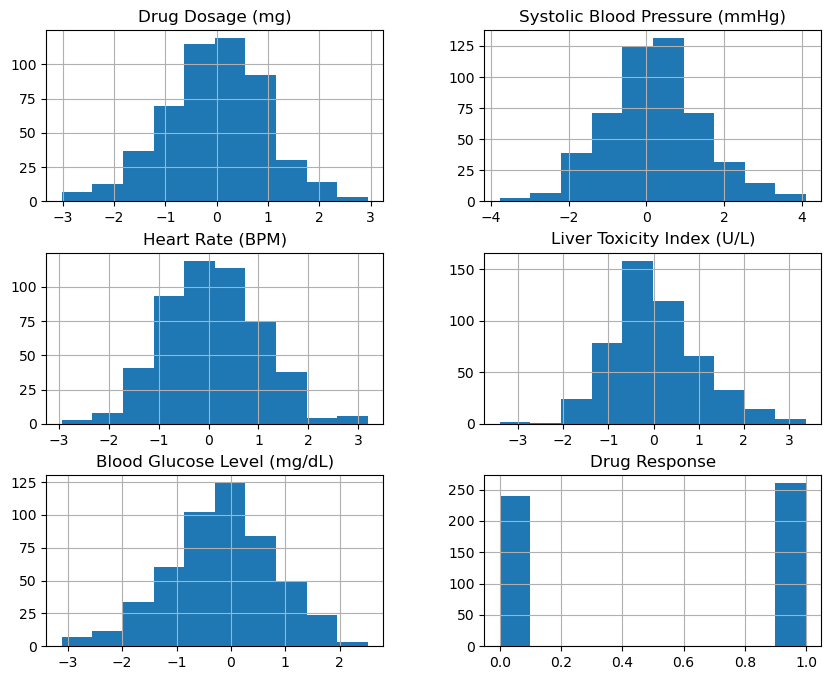

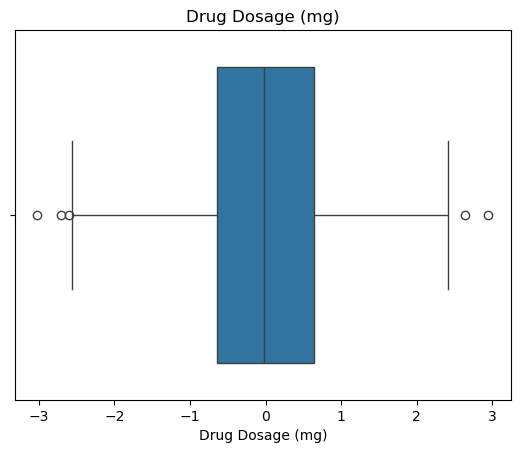

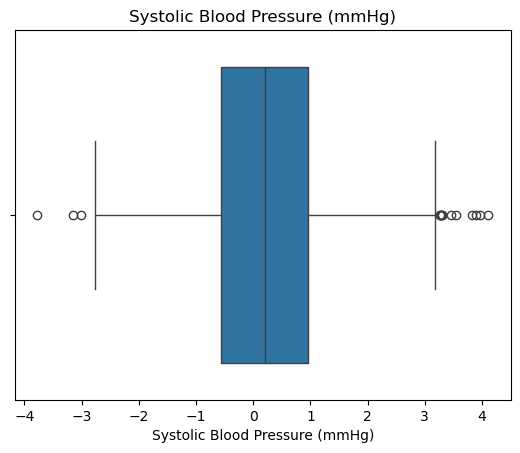

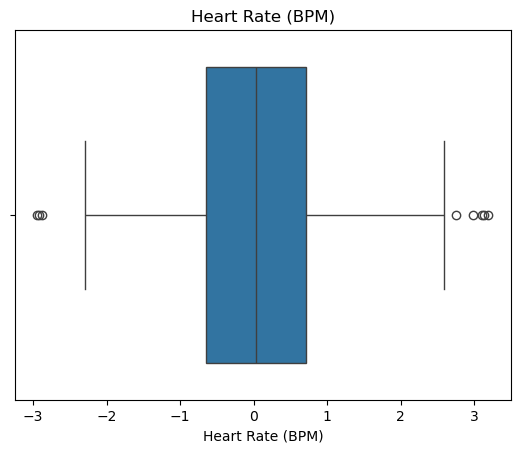

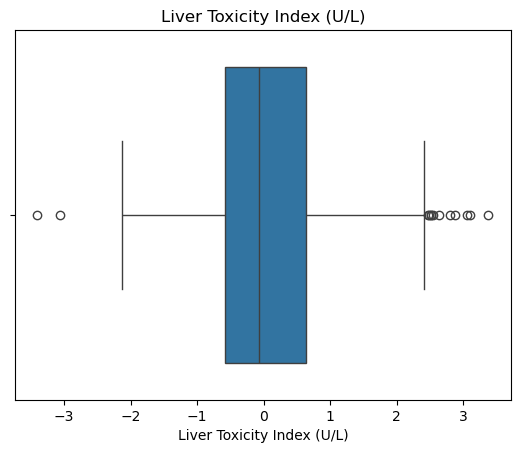

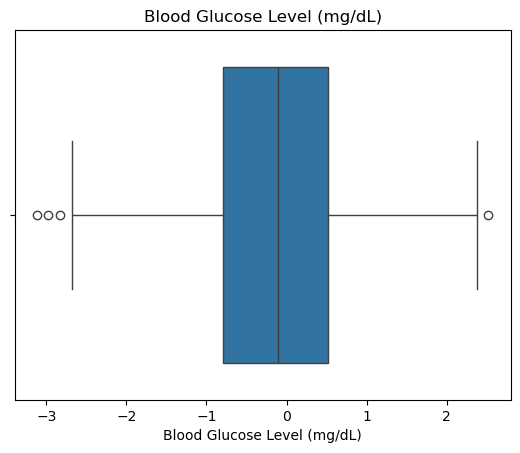

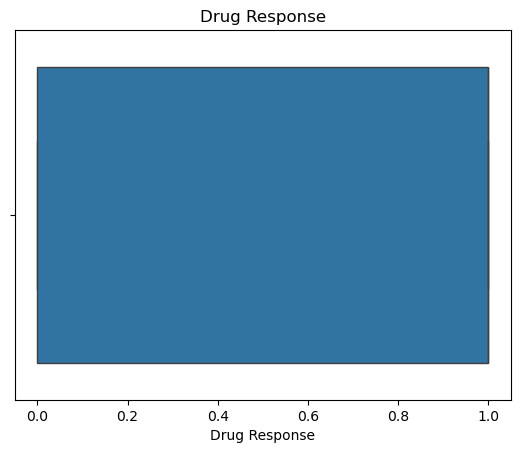

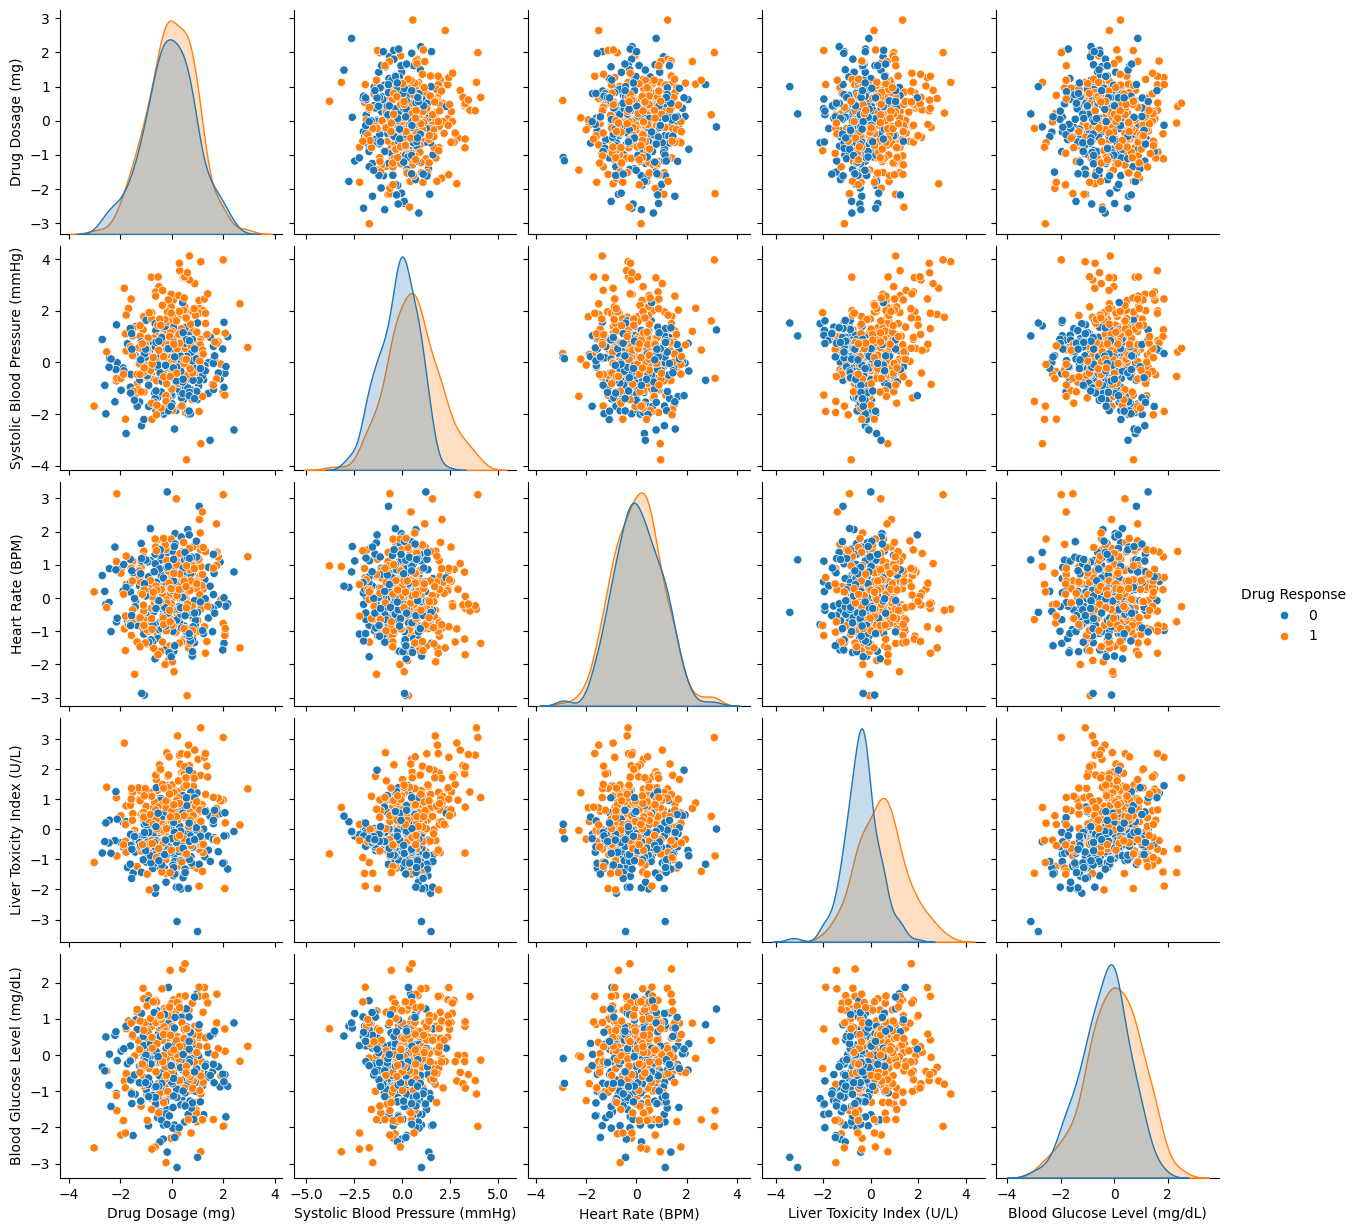

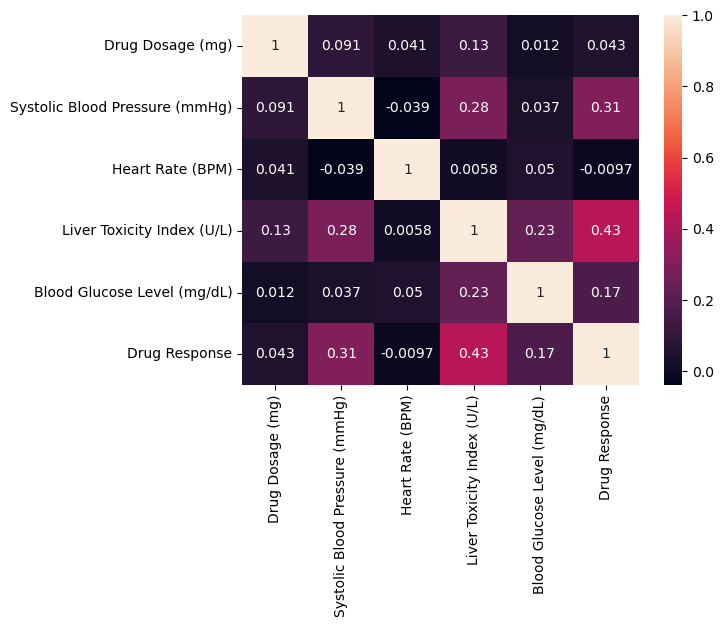

Accuracy: 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.76        44
           1       0.82      0.80      0.81        56

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100

ROC-AUC Score: 0.8299512987012987


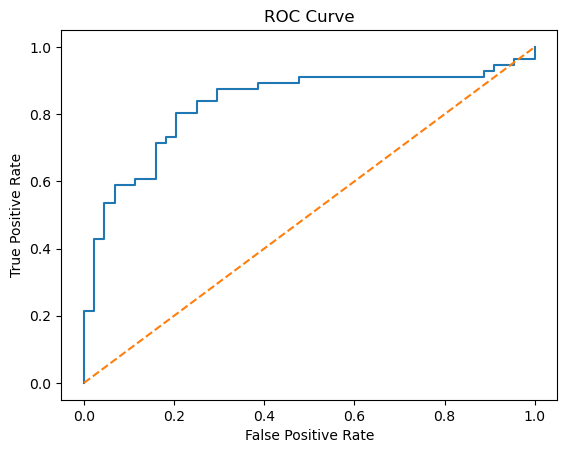


Feature Importance:

                          Feature  Coefficient
3      Liver Toxicity Index (U/L)     1.007959
1  Systolic Blood Pressure (mmHg)     0.504456
4     Blood Glucose Level (mg/dL)     0.200888
2                Heart Rate (BPM)    -0.016668
0                Drug Dosage (mg)    -0.052081


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

df = pd.read_csv("C:/Users/jeevitha/Downloads/Pharma_Industry.csv")   

df.columns = df.columns.str.strip()

print(df.head())
print(df.info())
print(df.describe())

# Histograms
df.hist(figsize=(10,8))
plt.show()

# Boxplots
for col in df.select_dtypes(include=np.number):
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Pairplot
target_column = df.columns[-1]
sns.pairplot(df, hue=target_column)
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

df.replace('?', np.nan, inplace=True)

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include='number'):
    df[col] = df[col].fillna(df[col].median())

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

target_column = df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print("\nFeature Importance:\n")
print(coefficients.sort_values(by='Coefficient', ascending=False))

#### Support Vector Machine

#### Task 1: Exploratory Data Analysis (EDA)

1. Load the dataset and perform fundamental data exploration.

2. Utilize histograms, box plots, or density plots to understand feature distributions.

3. Investigate feature correlations to discern relationships within the data.

#### Task 2: Data Preprocessing

1. Encode categorical variables if necessary.

2. Split the dataset into training and testing sets

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 

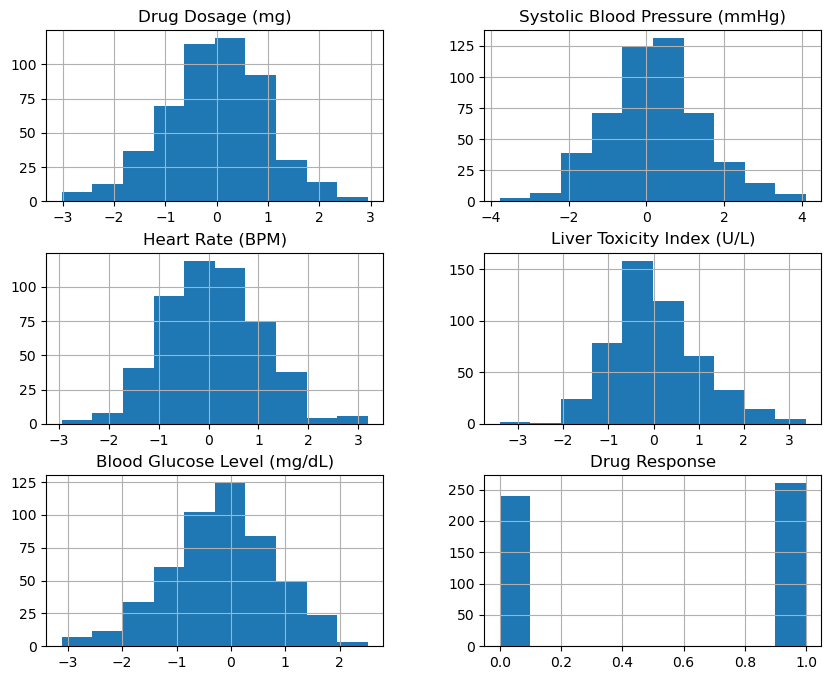

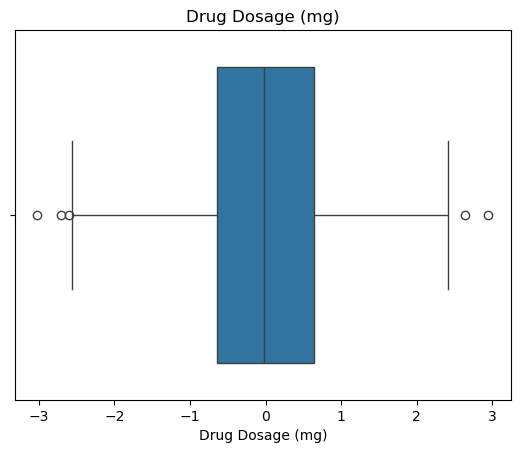

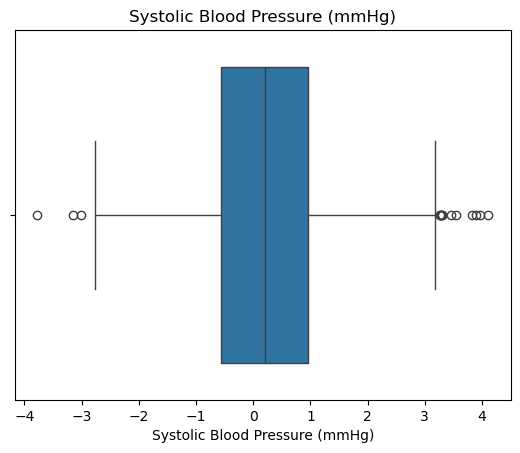

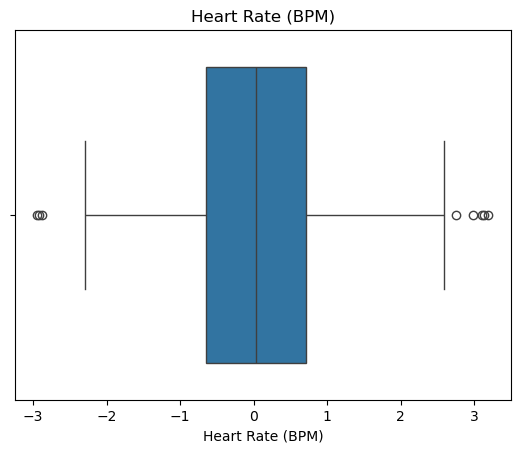

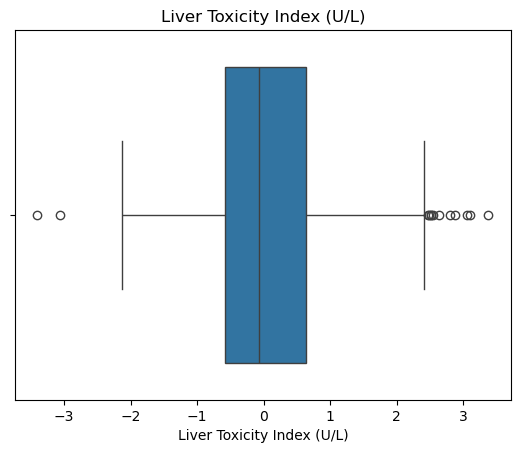

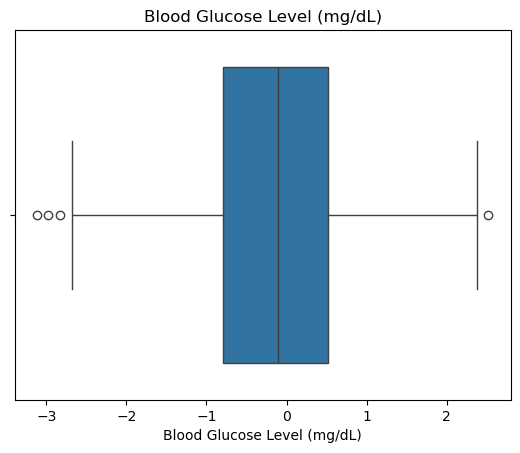

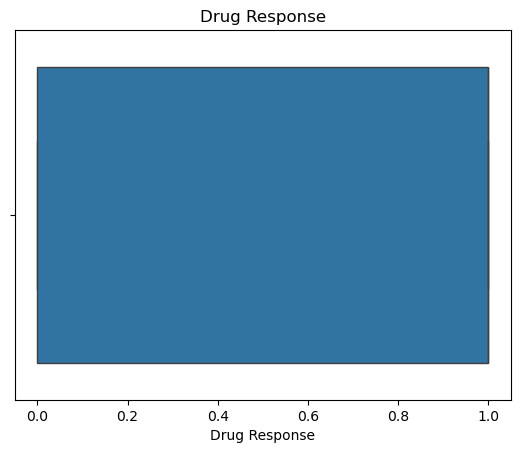

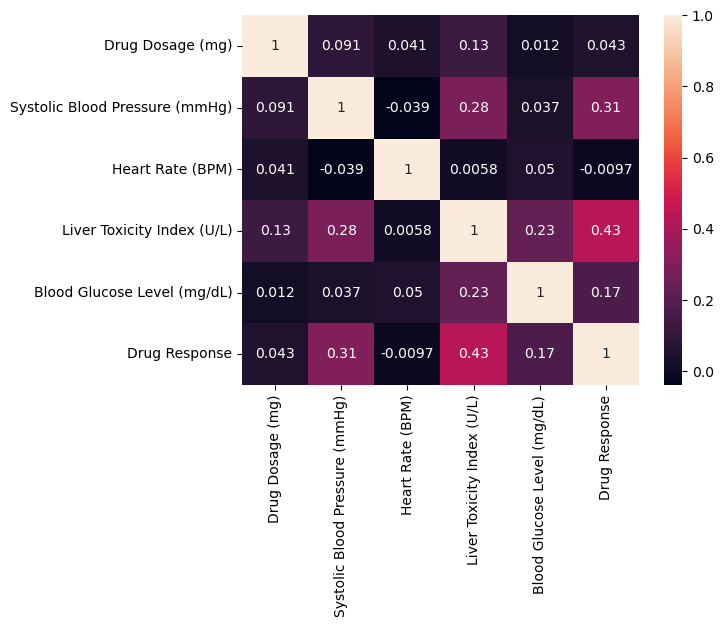

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("C:/Users/jeevitha/Downloads/Pharma_Industry.csv")  
df.columns = df.columns.str.strip()

print(df.head())
print(df.info())
print(df.describe())

# Histograms
df.hist(figsize=(10,8))
plt.show()

# Boxplots
for col in df.select_dtypes(include=np.number):
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()
# Handle missing values
df.replace('?', np.nan, inplace=True)

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include='number'):
    df[col] = df[col].fillna(df[col].median())

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Split data
target_column = df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data (VERY IMPORTANT for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#### Task 3: Data Visualization

1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

2. Visualize class distributions to gauge dataset balance or imbalance.

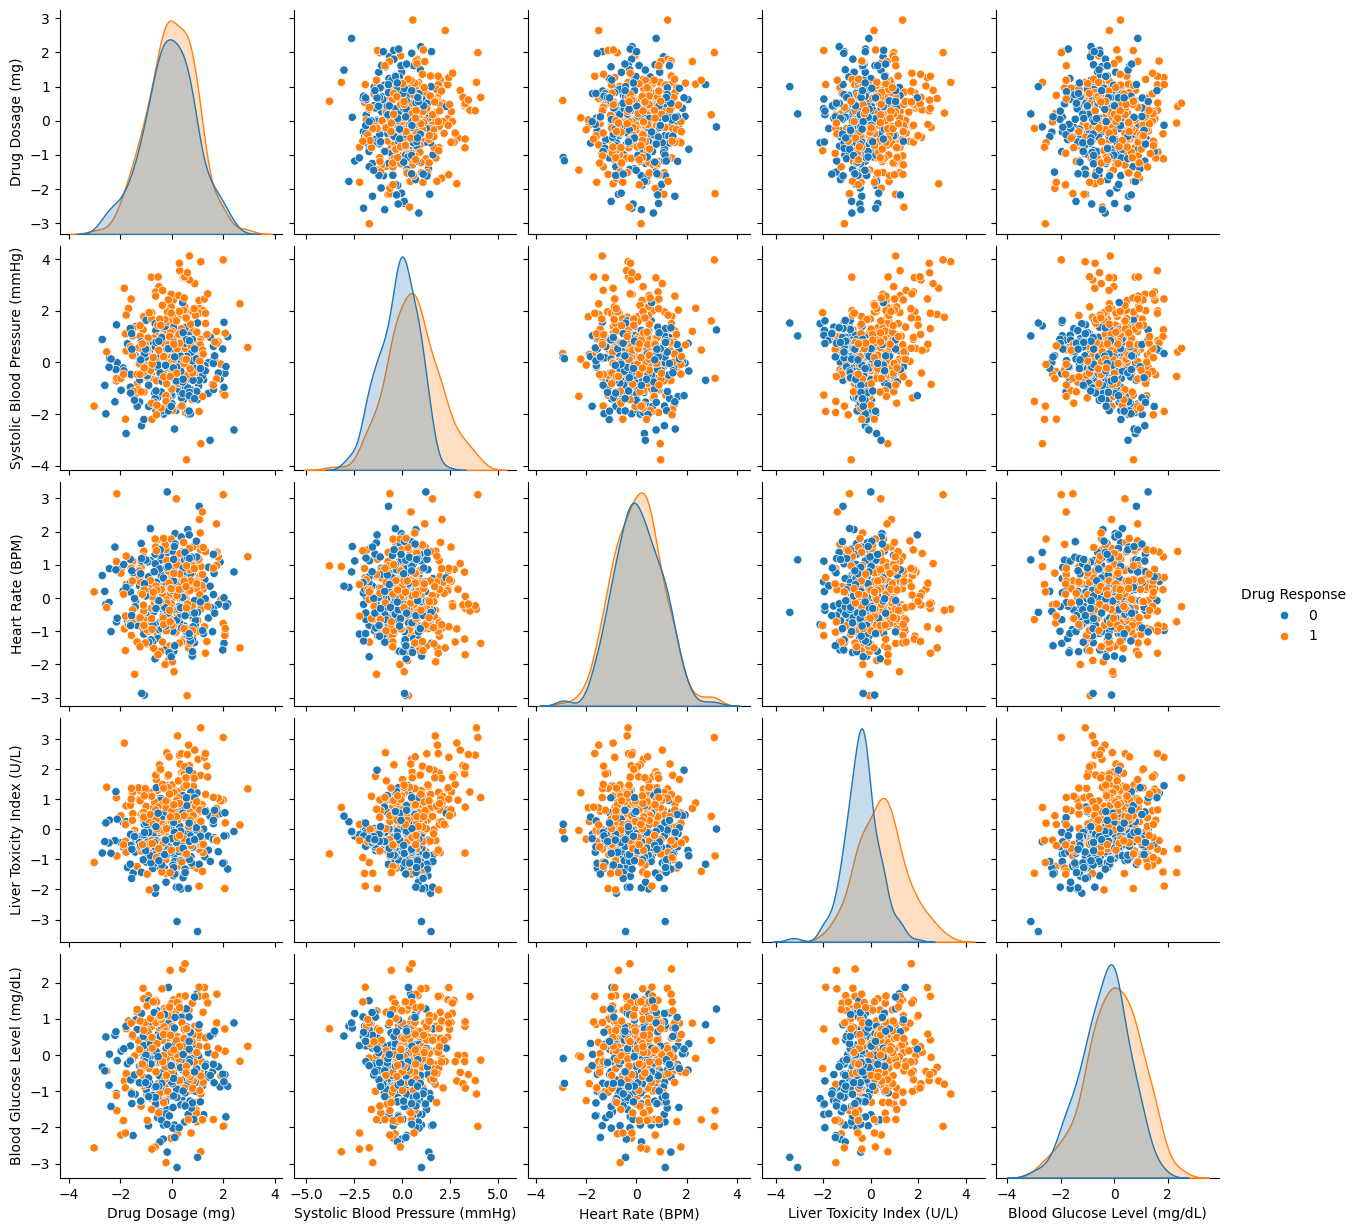

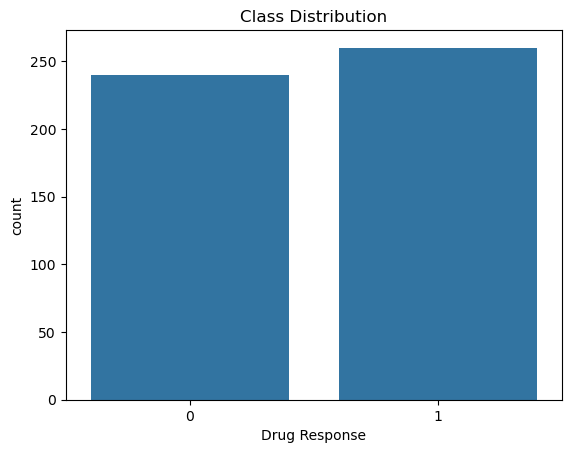

In [12]:
# Pairplot
sns.pairplot(df, hue=target_column)
plt.show()

# Class distribution
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()


#### Task 4: SVM Implementation

1. Implement a basic SVM classifier using Python libraries like scikit-learn.

2. Train the SVM model on the training data.

3. Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [13]:
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.78

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



#### Task 5: Visualization of SVM Results

1. Visualize classification results on the testing data

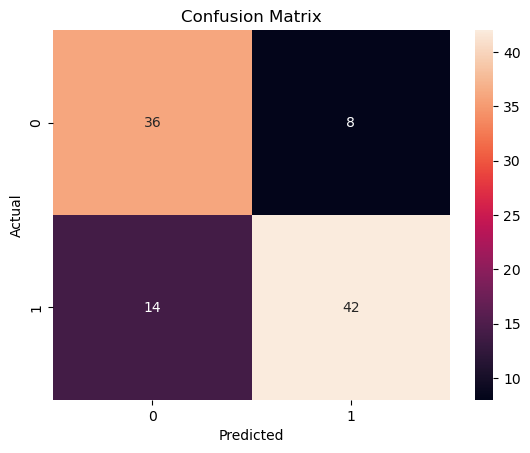

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Task 6: Parameter Tuning and Optimization

1. Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [15]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Optimized Accuracy: 0.84


#### Task 7: Comparison and Analysis

1. Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2. Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

3. Discuss practical implications of SVM in real-world classification tasks.

In [16]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"\nKernel: {k}")
    print("Accuracy:", accuracy_score(y_test, pred))


Kernel: linear
Accuracy: 0.78

Kernel: rbf
Accuracy: 0.84

Kernel: poly
Accuracy: 0.71
